In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [3]:
df = pd.read_csv("/content/Churn_Modelling.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nInfo:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())
print("\nClass distribution (Exited):")
print(df["Exited"].value_counts())

Shape: (10000, 14)

First 5 rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3       

In [4]:
# Drop irrelevant columns — no predictive power
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

# Separate features and target
X = df.drop(columns=["Exited"])
y = df["Exited"]

# Label Encode 'Gender' (binary — 2 categories)
le = LabelEncoder()
X["Gender"] = le.fit_transform(X["Gender"])
print(f"Gender classes: {le.classes_} → {list(range(len(le.classes_)))}")

# OneHot Encode 'Geography' (3 unordered categories — k-1 rule)
X = pd.get_dummies(X, columns=["Geography"], drop_first=True)

print("\nFeatures after encoding:")
print(X.head())
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass distribution:\n{y.value_counts()}")

Gender classes: ['Female' 'Male'] → [0, 1]

Features after encoding:
   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  
0               1        101348.88              False            False  
1               1        112542.58              False             True  
2               0        113931.57              False            False  
3               0         93826.63              False            False  
4               1         79084.10              False             True  

X shape: (10000, 11)
y shape: (1000

In [5]:
# Split FIRST before scaling (avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# StandardScaler — ANN uses gradient-based optimization, sensitive to feature scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

Training samples : 8000
Testing  samples : 2000
Features         : 11


In [6]:
# Initialize Sequential ANN
ann = Sequential([
    # Input + First Hidden Layer (11 features input, 6 neurons)
    Dense(units=6, activation="relu", input_shape=(X_train.shape[1],)),

    # Second Hidden Layer
    Dense(units=6, activation="relu"),

    # Output Layer — sigmoid for binary classification (1 neuron)
    Dense(units=1, activation="sigmoid")
])

# Display model summary
ann.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile the ANN
ann.compile(
    optimizer="adam",              # adaptive gradient descent
    loss="binary_crossentropy",    # binary classification loss
    metrics=["accuracy"]           # track accuracy during training
)

print("Model compiled successfully!")
print(f"Optimizer : Adam")
print(f"Loss      : Binary Crossentropy")
print(f"Metric    : Accuracy")

Model compiled successfully!
Optimizer : Adam
Loss      : Binary Crossentropy
Metric    : Accuracy


In [8]:
# Train the ANN
history = ann.fit(
    X_train, y_train,
    batch_size=32,        # process 32 samples at a time
    epochs=100,           # train for 100 full passes
    validation_split=0.2, # use 20% of training data for validation
    verbose=1             # show training progress
)

print("\nTraining complete!")
print(f"Final Training Accuracy  : {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7553 - loss: 0.5917 - val_accuracy: 0.7987 - val_loss: 0.5097
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.4951 - val_accuracy: 0.7987 - val_loss: 0.4662
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.4672 - val_accuracy: 0.7987 - val_loss: 0.4466
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.4537 - val_accuracy: 0.7987 - val_loss: 0.4370
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7934 - loss: 0.4466 - val_accuracy: 0.7987 - val_loss: 0.4322
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7934 - loss: 0.4422 - val_accuracy: 0.7987 - val_loss: 0.4291
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7934 - loss: 0.4395 - val_accuracy: 0.7987 - val_loss: 0.4270
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7934 - loss: 0.4376 - val_accu

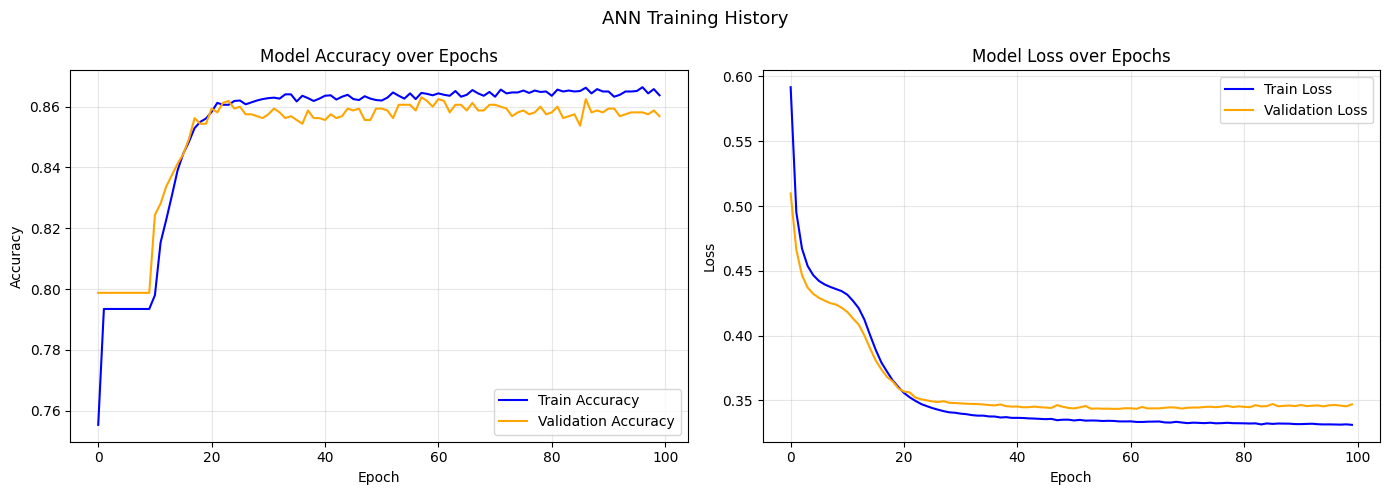

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history["accuracy"],     label="Train Accuracy",      color="blue")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy", color="orange")
axes[0].set_title("Model Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history["loss"],     label="Train Loss",      color="blue")
axes[1].plot(history.history["val_loss"], label="Validation Loss", color="orange")
axes[1].set_title("Model Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("ANN Training History", fontsize=13)
plt.tight_layout()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy: 85.50%


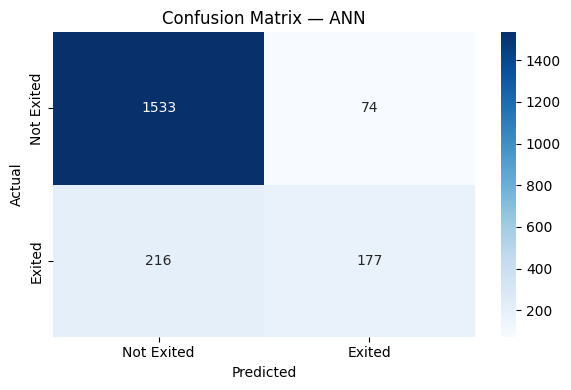


Classification Report:
              precision    recall  f1-score   support

  Not Exited       0.88      0.95      0.91      1607
      Exited       0.71      0.45      0.55       393

    accuracy                           0.85      2000
   macro avg       0.79      0.70      0.73      2000
weighted avg       0.84      0.85      0.84      2000



In [10]:
# Predict on test set
y_pred_prob = ann.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # convert probability to 0 or 1

# Accuracy
print(f"Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Exited", "Exited"],
            yticklabels=["Not Exited", "Exited"])
plt.title("Confusion Matrix — ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=["Not Exited", "Exited"]))

In [11]:
# Save the trained model
ann.save("churn_ann_model.keras")
print("Model saved as churn_ann_model.keras")

# Test a single customer prediction
# [CreditScore, Gender, Age, Tenure, Balance, NumOfProducts,
#  HasCrCard, IsActiveMember, EstimatedSalary, Geography_Germany, Geography_Spain]
single_customer = np.array([[600, 1, 40, 3, 60000, 2, 1, 1, 50000, 0, 1]])
single_scaled   = scaler.transform(single_customer)
prediction      = ann.predict(single_scaled)
result          = "Will EXIT the bank" if prediction[0][0] > 0.5 else "Will STAY in the bank"

print(f"\nSingle Customer Prediction:")
print(f"  Raw probability : {prediction[0][0]:.4f}")
print(f"  Prediction      : {result}")

Model saved as churn_ann_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Single Customer Prediction:
  Raw probability : 0.0249
  Prediction      : Will STAY in the bank


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
